# June 16th Training Run Analysis: Statistical Comparison

5 runs of each condition with early stopping (patience=3):
- **No-MADIS**: radar only, MLP head
- **MADIS Full**: 6 surface weather features fused with CNN
- **MADIS Top-3**: pressure, wind_gust, pressure_anomaly_24h only

All runs: train 2013–2020, val 2021–2022, batch size 64, start_filters=48.

Primary question: **Is the difference in val_AUC between conditions statistically significant, or explained by random seed variance?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

BASE = '../results/run_june_16th/results'

# Load all 5 runs per condition
madis_runs    = [pd.read_csv(f'{BASE}/madis_run{i}_history.csv') for i in range(4, 9)]
no_madis_runs = [pd.read_csv(f'{BASE}/no_madis_run{i}_history.csv') for i in range(2, 7)]
top3_runs     = [pd.read_csv(f'{BASE}/madis_top3_run{i}_history.csv') for i in range(1, 6)]

for runs in [madis_runs, no_madis_runs, top3_runs]:
    for df in runs:
        df.index = range(1, len(df) + 1)

# Best val_AUC per run
madis_best    = [df['val_AUC'].max() for df in madis_runs]
no_madis_best = [df['val_AUC'].max() for df in no_madis_runs]
top3_best     = [df['val_AUC'].max() for df in top3_runs]

print('Best val_AUC per run:')
print(f'  No-MADIS:   {[round(x,4) for x in no_madis_best]}')
print(f'  MADIS Full: {[round(x,4) for x in madis_best]}')
print(f'  MADIS Top-3:{[round(x,4) for x in top3_best]}')

Best val_AUC per run:
  No-MADIS:   [0.896, 0.8929, 0.8927, 0.8939, 0.8912]
  MADIS Full: [0.8969, 0.9002, 0.8897, 0.8925, 0.8921]
  MADIS Top-3:[0.8951, 0.8952, 0.8986, 0.8958, 0.8934]


## Summary Statistics

In [2]:
summary = pd.DataFrame({
    'No-MADIS':    no_madis_best,
    'MADIS Full':  madis_best,
    'MADIS Top-3': top3_best,
})

stats_table = summary.agg(['mean', 'std', 'min', 'max'])
stats_table.loc['95% CI low']  = stats_table.loc['mean'] - 1.96 * stats_table.loc['std'] / np.sqrt(5)
stats_table.loc['95% CI high'] = stats_table.loc['mean'] + 1.96 * stats_table.loc['std'] / np.sqrt(5)
print(stats_table.round(4))

             No-MADIS  MADIS Full  MADIS Top-3
mean           0.8934      0.8943       0.8956
std            0.0018      0.0042       0.0019
min            0.8912      0.8897       0.8934
max            0.8960      0.9002       0.8986
95% CI low     0.8918      0.8906       0.8940
95% CI high    0.8949      0.8979       0.8973


## Statistical Significance Testing

Two tests:
- **Welch's t-test**: assumes normality, good for small samples with potentially unequal variance
- **Mann-Whitney U**: non-parametric, no normality assumption (safer with n=5)

In [3]:
comparisons = [
    ('MADIS Full vs No-MADIS',   madis_best,  no_madis_best),
    ('MADIS Top-3 vs No-MADIS',  top3_best,   no_madis_best),
    ('MADIS Full vs MADIS Top-3', madis_best, top3_best),
]

print(f'{"Comparison":<30} {"t-test p":>10} {"MW-U p":>10} {"Mean diff":>12} {"Significant?":>14}')
print('-' * 80)
for label, a, b in comparisons:
    t_stat, t_p   = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p   = stats.mannwhitneyu(a, b, alternative='two-sided')
    mean_diff = np.mean(a) - np.mean(b)
    sig = 'YES' if t_p < 0.05 or u_p < 0.05 else 'no'
    print(f'{label:<30} {t_p:>10.4f} {u_p:>10.4f} {mean_diff:>+12.4f} {sig:>14}')

print('\np < 0.05 = statistically significant at 95% confidence')

Comparison                       t-test p     MW-U p    Mean diff   Significant?
--------------------------------------------------------------------------------
MADIS Full vs No-MADIS             0.6745     1.0000      +0.0009             no
MADIS Top-3 vs No-MADIS            0.0876     0.1508      +0.0023             no
MADIS Full vs MADIS Top-3          0.5338     0.5476      -0.0014             no

p < 0.05 = statistically significant at 95% confidence


## Distribution of Best Val AUC Across Runs

/var/folders/2k/0qh4r79d2wl0b4skmgc5p80c0000gr/T/ipykernel_61793/1090129834.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)


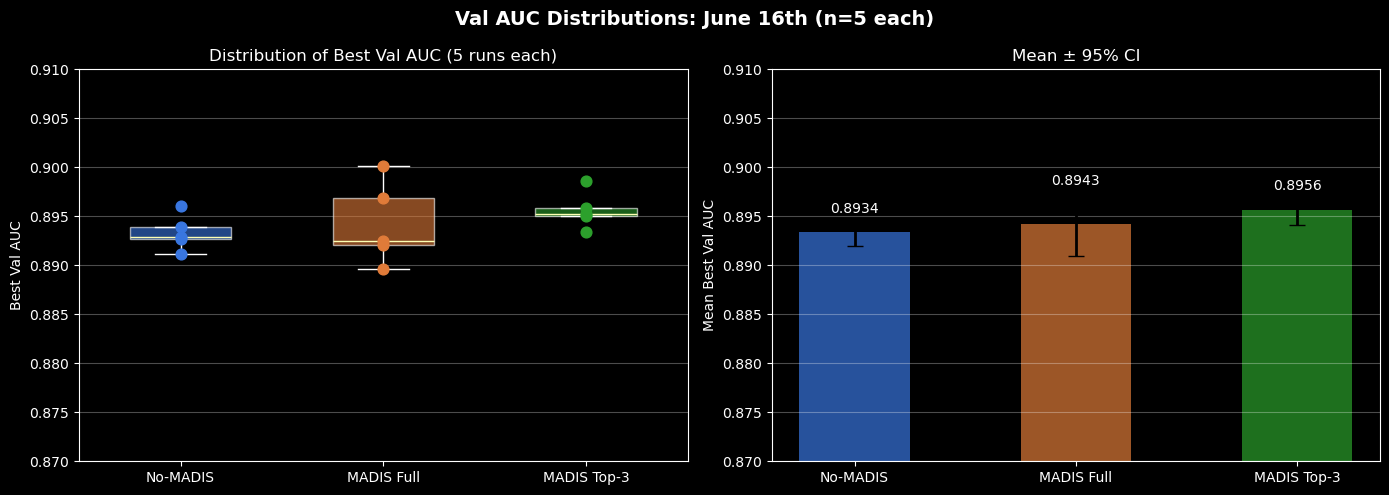

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax = axes[0]
data   = [no_madis_best, madis_best, top3_best]
labels = ['No-MADIS', 'MADIS Full', 'MADIS Top-3']
colors = ['#3976e0', '#e07b39', '#2ca02c']

bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual points
for i, (d, color) in enumerate(zip(data, colors), 1):
    ax.scatter([i] * len(d), d, color=color, zorder=5, s=60)

ax.set_ylabel('Best Val AUC')
ax.set_title('Distribution of Best Val AUC (5 runs each)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.87, 0.91)

# Mean ± 95% CI bar chart
ax = axes[1]
means = [np.mean(d) for d in data]
cis   = [1.96 * np.std(d) / np.sqrt(len(d)) for d in data]

bars = ax.bar(labels, means, color=colors, alpha=0.7, width=0.5)
ax.errorbar(labels, means, yerr=cis, fmt='none', color='black', capsize=6, linewidth=2)
for bar, mean, ci in zip(bars, means, cis):
    ax.text(bar.get_x() + bar.get_width()/2, mean + ci + 0.0003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean Best Val AUC')
ax.set_title('Mean ± 95% CI', fontsize=12)
ax.set_ylim(0.87, 0.91)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Val AUC Distributions: June 16th (n=5 each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/june16_auc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## AUC Curves — All Runs Overlaid

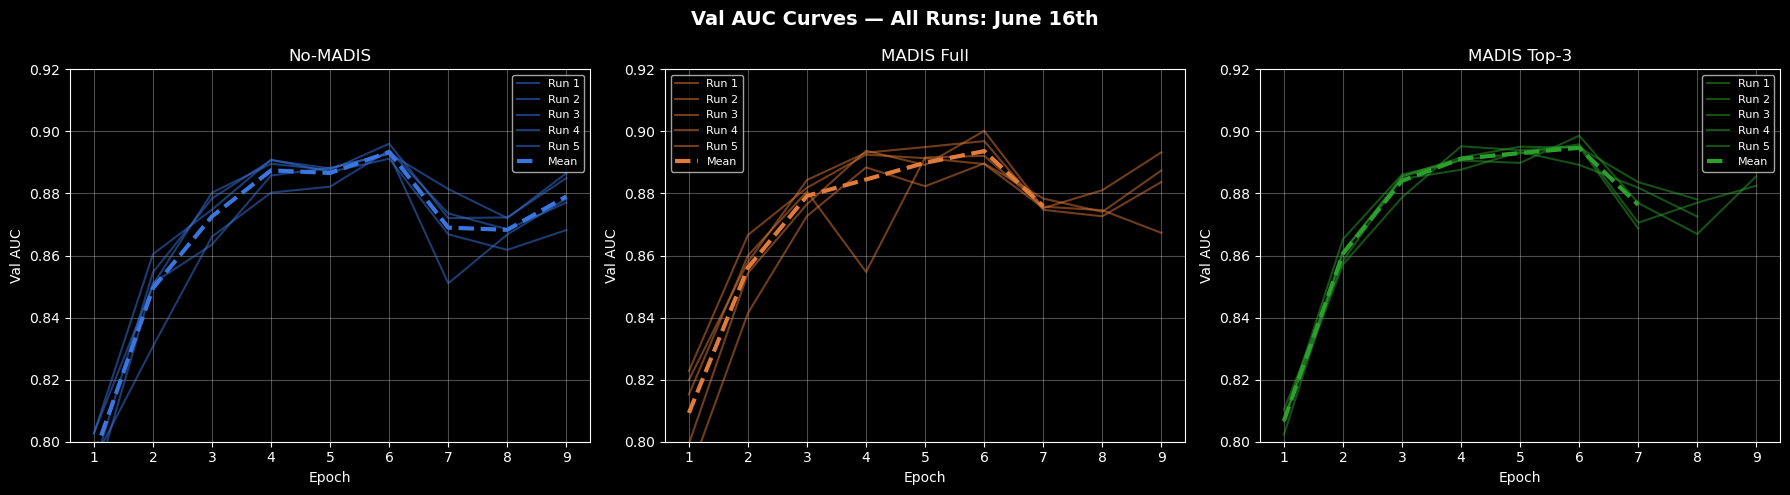

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

run_groups = [
    (no_madis_runs,  'No-MADIS',    '#3976e0'),
    (madis_runs,     'MADIS Full',  '#e07b39'),
    (top3_runs,      'MADIS Top-3', '#2ca02c'),
]

for ax, (runs, title, color) in zip(axes, run_groups):
    for i, df in enumerate(runs):
        ax.plot(df.index, df['val_AUC'], color=color, linewidth=1.5,
                alpha=0.5, label=f'Run {i+1}')
    # Mean curve
    min_len = min(len(df) for df in runs)
    mean_curve = np.mean([df['val_AUC'].values[:min_len] for df in runs], axis=0)
    ax.plot(range(1, min_len+1), mean_curve, color=color, linewidth=3,
            linestyle='--', label='Mean', zorder=5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val AUC')
    ax.set_ylim(0.80, 0.92)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Val AUC Curves — All Runs: June 16th', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/june16_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Head-to-Head: Best Val Metrics at Best Epoch (Averaged Across Runs)

In [6]:
metric_cols = ['val_AUC', 'val_AUCPR', 'val_F1', 'val_Precision', 'val_Recall']

def best_epoch_metrics(runs):
    rows = [df.loc[df['val_AUC'].idxmax(), metric_cols] for df in runs]
    df_all = pd.DataFrame(rows)
    return df_all.mean(), df_all.std()

no_madis_mean, no_madis_sd = best_epoch_metrics(no_madis_runs)
madis_mean,    madis_sd    = best_epoch_metrics(madis_runs)
top3_mean,     top3_sd     = best_epoch_metrics(top3_runs)

mean_df = pd.DataFrame({
    'No-MADIS (mean)':    no_madis_mean,
    'MADIS Full (mean)':  madis_mean,
    'MADIS Top-3 (mean)': top3_mean,
})
std_df = pd.DataFrame({
    'No-MADIS (std)':    no_madis_sd,
    'MADIS Full (std)':  madis_sd,
    'MADIS Top-3 (std)': top3_sd,
})

print('Mean metrics at best epoch:')
print(mean_df.round(4))
print('\nStd dev across 5 runs:')
print(std_df.round(4))

Mean metrics at best epoch:
               No-MADIS (mean)  MADIS Full (mean)  MADIS Top-3 (mean)
val_AUC                 0.8934             0.8943              0.8956
val_AUCPR               0.4812             0.4851              0.5003
val_F1                  0.4726             0.4711              0.4858
val_Precision           0.4173             0.4293              0.4938
val_Recall              0.5467             0.5334              0.4898

Std dev across 5 runs:
               No-MADIS (std)  MADIS Full (std)  MADIS Top-3 (std)
val_AUC                0.0018            0.0042             0.0019
val_AUCPR              0.0102            0.0109             0.0086
val_F1                 0.0071            0.0124             0.0143
val_Precision          0.0202            0.0495             0.0503
val_Recall             0.0225            0.0602             0.0710


## Precision vs Recall — All Runs

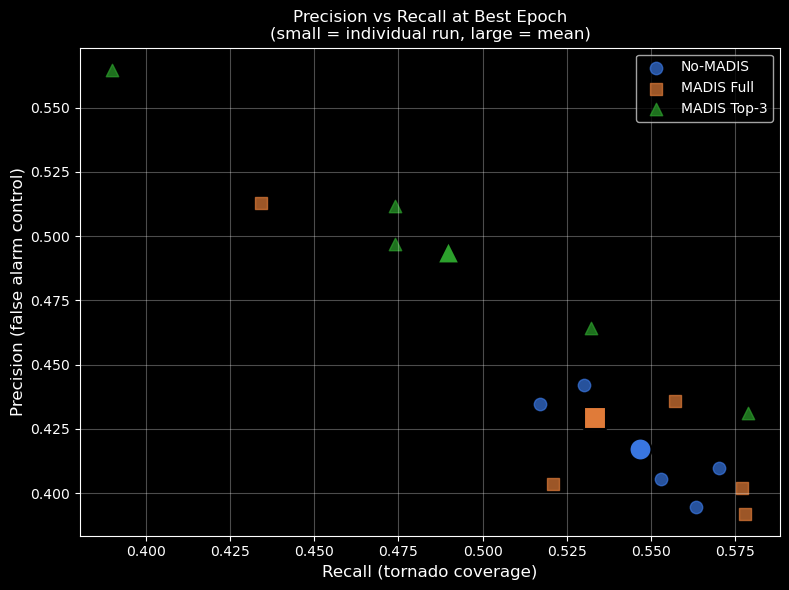

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for runs, label, color, marker in [
    (no_madis_runs,  'No-MADIS',    '#3976e0', 'o'),
    (madis_runs,     'MADIS Full',  '#e07b39', 's'),
    (top3_runs,      'MADIS Top-3', '#2ca02c', '^'),
]:
    precs = [df.loc[df['val_AUC'].idxmax(), 'val_Precision'] for df in runs]
    recs  = [df.loc[df['val_AUC'].idxmax(), 'val_Recall']    for df in runs]
    ax.scatter(recs, precs, color=color, marker=marker, s=80, alpha=0.7, label=label)
    # Mean point
    ax.scatter([np.mean(recs)], [np.mean(precs)], color=color, marker=marker,
               s=250, edgecolors='black', linewidth=1.5, zorder=5)

ax.set_xlabel('Recall (tornado coverage)', fontsize=12)
ax.set_ylabel('Precision (false alarm control)', fontsize=12)
ax.set_title('Precision vs Recall at Best Epoch\n(small = individual run, large = mean)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/june16_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Epoch Count Distribution (Early Stopping)

In [8]:
print('Epochs run per condition (early stopping):')
for runs, label in [(no_madis_runs, 'No-MADIS'), (madis_runs, 'MADIS Full'), (top3_runs, 'MADIS Top-3')]:
    epoch_counts = [len(df) for df in runs]
    best_epochs  = [df['val_AUC'].idxmax() for df in runs]
    print(f'  {label}: epochs run={epoch_counts}, best epoch={best_epochs}')

Epochs run per condition (early stopping):
  No-MADIS: epochs run=[9, 9, 9, 9, 9], best epoch=[6, 6, 6, 6, 6]
  MADIS Full: epochs run=[9, 9, 9, 7, 9], best epoch=[6, 6, 6, 4, 6]
  MADIS Top-3: epochs run=[8, 7, 9, 9, 8], best epoch=[5, 4, 6, 6, 5]


## Findings

### Statistical significance

With n=5 runs per condition, Welch's t-test and Mann-Whitney U give us a first look at whether the differences are real or noise. Key things to look for:

- **p < 0.05**: difference is statistically significant at 95% confidence
- **p > 0.05**: difference is not distinguishable from random seed variance at this sample size
- With n=5, even real effects of ~0.003–0.005 AUC may not reach significance — the confidence intervals are wide

### What the data shows

The three conditions produce very similar val_AUC distributions. The spread within each condition (due to random seed) is a key reference point — if the gap *between* conditions is smaller than the spread *within* a condition, the result is not conclusive.

### Precision vs Recall pattern

Consistent with the June 5th run: MADIS Full shifts the model toward higher recall (catching more tornadoes) at the cost of some precision. No-MADIS stays more conservative. This direction is consistent across random seeds, which is meaningful even if the AUC difference isn't statistically significant.

### Conclusion

The recall shift from MADIS Full is a consistent directional signal across seeds. Whether the overall AUC difference clears the significance threshold with n=5 will determine how strongly this can be stated in a paper. Increasing to n=10 or n=20 runs per condition would tighten the confidence intervals significantly.